In [1]:
import numpy as np
import pandas as pd


def softmax(x):
    x = np.asarray(x, dtype=float)
    x = x - np.max(x)
    ex = np.exp(x)
    return ex / ex.sum()


def simulate_timeseries_sc(
    n_timepoints=5,
    reps_per_time=3,
    cells_per_sample=300,
    n_cell_types=3,
    genes_per_program=None,
    seed=1,
    library_scale=1.0,
    dispersion_theta=20.0,
    dropout_rate=0.0,
    model="negbin"
):
    """
    Simulate time-series single-cell samples with cell types.

    Returns
    -------
    counts_df : pd.DataFrame
        gene x cell count matrix
    cell_meta : pd.DataFrame
        metadata for each cell
    sample_meta : pd.DataFrame
        metadata for each sample
    gene_meta : pd.DataFrame
        metadata for each gene
    pseudobulk_df : pd.DataFrame
        gene x sample pseudobulk count matrix
    composition_df : pd.DataFrame
        sample x cell-type proportion table
    """

    rng = np.random.default_rng(seed)

    if genes_per_program is None:
        genes_per_program = {
            "shared_early": 40,
            "shared_late": 40,
            "ct0_marker": 60,
            "ct1_marker": 60,
            "ct2_marker": 60,
            "dynamic_ct0": 40,
            "dynamic_ct1": 40,
            "dynamic_ct2": 40,
        }

    if n_cell_types != 3:
        raise ValueError("This starter version is written for n_cell_types=3.")

    cell_types = [f"CT{i}" for i in range(n_cell_types)]

    # --------------------------------------------------
    # 1) Define time grid and samples
    # --------------------------------------------------
    times = np.linspace(0, 1, n_timepoints)

    sample_rows = []
    for t_idx, t in enumerate(times):
        for rep in range(reps_per_time):
            sample_rows.append({
                "sample_id": f"S{t_idx}_R{rep}",
                "time_idx": t_idx,
                "time": t,
                "replicate": rep
            })
    sample_meta = pd.DataFrame(sample_rows)

    # --------------------------------------------------
    # 2) Define gene programs
    # --------------------------------------------------
    gene_records = []
    gene_names = []

    def add_genes(program_name, n, preferred_ct=None):
        start = len(gene_names)
        for i in range(n):
            g = f"G{start+i}"
            gene_names.append(g)
            gene_records.append({
                "gene_id": g,
                "program": program_name,
                "preferred_cell_type": preferred_ct
            })

    add_genes("shared_early", genes_per_program["shared_early"], None)
    add_genes("shared_late", genes_per_program["shared_late"], None)
    add_genes("ct0_marker", genes_per_program["ct0_marker"], "CT0")
    add_genes("ct1_marker", genes_per_program["ct1_marker"], "CT1")
    add_genes("ct2_marker", genes_per_program["ct2_marker"], "CT2")
    add_genes("dynamic_ct0", genes_per_program["dynamic_ct0"], "CT0")
    add_genes("dynamic_ct1", genes_per_program["dynamic_ct1"], "CT1")
    add_genes("dynamic_ct2", genes_per_program["dynamic_ct2"], "CT2")

    gene_meta = pd.DataFrame(gene_records)
    n_genes = len(gene_meta)

    # --------------------------------------------------
    # 3) Gene-level baseline / amplitudes
    # --------------------------------------------------
    gene_meta["baseline"] = rng.lognormal(mean=1.0, sigma=0.35, size=n_genes)
    gene_meta["marker_effect"] = rng.lognormal(mean=1.2, sigma=0.30, size=n_genes)
    gene_meta["dynamic_amp"] = rng.lognormal(mean=1.0, sigma=0.40, size=n_genes)

    # peak times for dynamic genes
    peak_map = {
        "dynamic_ct0": 0.2,
        "dynamic_ct1": 0.55,
        "dynamic_ct2": 0.8,
        "shared_early": 0.15,
        "shared_late": 0.85
    }
    gene_meta["peak_time"] = gene_meta["program"].map(peak_map).fillna(np.nan)
    gene_meta["sigma"] = rng.uniform(0.08, 0.18, size=n_genes)

    # --------------------------------------------------
    # 4) Cell-type composition over time
    #    CT0 decreases, CT1/CT2 increase
    # --------------------------------------------------
    def expected_composition(t):
        # logits
        z0 = 2.2 - 5.0 * t
        z1 = -0.2 + 2.6 * t
        z2 = -0.4 + 2.8 * t
        return softmax([z0, z1, z2])

    comp_rows = []
    for _, srow in sample_meta.iterrows():
        t = srow["time"]
        base_p = expected_composition(t)

        # add sample-level noise
        noisy = rng.dirichlet(40 * base_p)
        comp_rows.append({
            "sample_id": srow["sample_id"],
            "time": t,
            "CT0": noisy[0],
            "CT1": noisy[1],
            "CT2": noisy[2]
        })

    composition_df = pd.DataFrame(comp_rows)

    # --------------------------------------------------
    # 5) Sample cells according to composition
    # --------------------------------------------------
    cell_meta_rows = []
    cell_ids = []

    for _, srow in sample_meta.iterrows():
        sid = srow["sample_id"]
        t = srow["time"]

        comp = composition_df.loc[composition_df["sample_id"] == sid, ["CT0", "CT1", "CT2"]].values[0]
        n_ct = rng.multinomial(cells_per_sample, comp)

        for ct_i, ct in enumerate(cell_types):
            for k in range(n_ct[ct_i]):
                cid = f"{sid}_{ct}_{k}"
                cell_ids.append(cid)
                cell_meta_rows.append({
                    "cell_id": cid,
                    "sample_id": sid,
                    "time": t,
                    "time_idx": srow["time_idx"],
                    "replicate": srow["replicate"],
                    "cell_type": ct
                })

    cell_meta = pd.DataFrame(cell_meta_rows)
    n_cells = len(cell_meta)

    # --------------------------------------------------
    # 6) Mean expression model
    #    log-mu = baseline + celltype effect + time effect + cell noise
    # --------------------------------------------------
    def time_bump(t, peak, sigma):
        return np.exp(-((t - peak) ** 2) / (2 * sigma ** 2))

    mu = np.zeros((n_genes, n_cells), dtype=float)

    # optional sample-level size factors
    sample_sf = {
        sid: rng.lognormal(mean=0.0, sigma=0.15)
        for sid in sample_meta["sample_id"]
    }

    for j, crow in cell_meta.iterrows():
        ct = crow["cell_type"]
        t = crow["time"]
        sid = crow["sample_id"]

        # cell-specific library effect
        cell_sf = rng.lognormal(mean=0.0, sigma=0.20) * library_scale * sample_sf[sid]

        for i, grow in gene_meta.iterrows():
            val = grow["baseline"]

            prog = grow["program"]
            pref = grow["preferred_cell_type"]

            # marker effects
            if prog in ("ct0_marker", "ct1_marker", "ct2_marker"):
                if pref == ct:
                    val += grow["marker_effect"]
                else:
                    val += 0.1

            # dynamic cell-type-specific effects
            elif prog in ("dynamic_ct0", "dynamic_ct1", "dynamic_ct2"):
                if pref == ct:
                    val += grow["dynamic_amp"] * time_bump(t, grow["peak_time"], grow["sigma"])
                else:
                    val += 0.05

            # shared temporal effects
            elif prog == "shared_early":
                val += grow["dynamic_amp"] * time_bump(t, grow["peak_time"], grow["sigma"])

            elif prog == "shared_late":
                val += grow["dynamic_amp"] * time_bump(t, grow["peak_time"], grow["sigma"])

            mu[i, j] = max(val * cell_sf, 1e-4)

    # --------------------------------------------------
    # 7) Sample counts
    # --------------------------------------------------
    if model == "poisson":
        counts = rng.poisson(mu)

    elif model == "negbin":
        # Gamma-Poisson mixture with mean=mu, var=mu + mu^2/theta
        lam = rng.gamma(shape=dispersion_theta, scale=mu / dispersion_theta)
        counts = rng.poisson(lam)

    else:
        raise ValueError("model must be 'poisson' or 'negbin'")

    # --------------------------------------------------
    # 8) Optional dropout
    # --------------------------------------------------
    if dropout_rate > 0:
        drop_mask = rng.uniform(size=counts.shape) < dropout_rate
        counts[drop_mask] = 0

    counts_df = pd.DataFrame(counts, index=gene_meta["gene_id"], columns=cell_meta["cell_id"])

    # --------------------------------------------------
    # 9) Pseudobulk
    # --------------------------------------------------
    pseudobulk = []
    sample_ids = sample_meta["sample_id"].tolist()

    for sid in sample_ids:
        cols = cell_meta.loc[cell_meta["sample_id"] == sid, "cell_id"].tolist()
        pseudobulk.append(counts_df[cols].sum(axis=1).values)

    pseudobulk_df = pd.DataFrame(
        np.column_stack(pseudobulk),
        index=gene_meta["gene_id"],
        columns=sample_ids
    )

    return counts_df, cell_meta, sample_meta, gene_meta, pseudobulk_df, composition_df

In [2]:
counts_df, cell_meta, sample_meta, gene_meta, pseudobulk_df, composition_df = simulate_timeseries_sc(
    n_timepoints=4,
    reps_per_time=3,
    cells_per_sample=250,
    seed=42,
    model="negbin",
    dropout_rate=0.05
)

print(counts_df.shape)
print(cell_meta.head())
print(sample_meta.head())
print(gene_meta["program"].value_counts())
print(composition_df.head())
print(pseudobulk_df.shape)

(380, 3000)
       cell_id sample_id  time  time_idx  replicate cell_type
0  S0_R0_CT0_0     S0_R0   0.0         0          0       CT0
1  S0_R0_CT0_1     S0_R0   0.0         0          0       CT0
2  S0_R0_CT0_2     S0_R0   0.0         0          0       CT0
3  S0_R0_CT0_3     S0_R0   0.0         0          0       CT0
4  S0_R0_CT0_4     S0_R0   0.0         0          0       CT0
  sample_id  time_idx      time  replicate
0     S0_R0         0  0.000000          0
1     S0_R1         0  0.000000          1
2     S0_R2         0  0.000000          2
3     S1_R0         1  0.333333          0
4     S1_R1         1  0.333333          1
program
ct0_marker      60
ct1_marker      60
ct2_marker      60
shared_early    40
shared_late     40
dynamic_ct0     40
dynamic_ct1     40
dynamic_ct2     40
Name: count, dtype: int64
  sample_id      time       CT0       CT1       CT2
0     S0_R0  0.000000  0.906283  0.069124  0.024593
1     S0_R1  0.000000  0.830705  0.054234  0.115061
2     S0_R2  0.0

In [10]:
cell_meta.columns

Index(['cell_id', 'sample_id', 'time', 'time_idx', 'replicate', 'cell_type'], dtype='object')

In [12]:
cell_meta.groupby('time')['cell_type'].value_counts()

time      cell_type
0.000000  CT0          625
          CT2           73
          CT1           52
0.333333  CT1          307
          CT0          247
          CT2          196
0.666667  CT2          380
          CT1          345
          CT0           25
1.000000  CT2          423
          CT1          327
Name: count, dtype: int64

In [13]:
gene_meta

,gene_id,program,preferred_cell_type,baseline,marker_effect,dynamic_amp,peak_time,sigma
0,G0,shared_early,None,3.024213,3.429327,4.481089,0.15,0.126468
1,G1,shared_early,None,1.888921,4.917819,3.504853,0.15,0.116790
2,G2,shared_early,None,3.534804,2.053041,3.654670,0.15,0.101919
3,G3,shared_early,None,3.778011,2.280753,3.507005,0.15,0.100838
4,G4,shared_early,None,1.373192,2.053646,3.115272,0.15,0.155149
...,...,...,...,...,...,...,...,...
375,G375,dynamic_ct2,CT2,6.139103,4.668392,4.551140,0.80,0.123882
376,G376,dynamic_ct2,CT2,2.529934,2.518705,2.786209,0.80,0.110296
377,G377,dynamic_ct2,CT2,1.348196,4.290940,2.759063,0.80,0.116927
378,G378,dynamic_ct2,CT2,4.765913,4.022437,2.623427,0.80,0.103600


In [11]:
cell_meta['cell_type'].value_counts()

cell_type
CT2    1072
CT1    1031
CT0     897
Name: count, dtype: int64

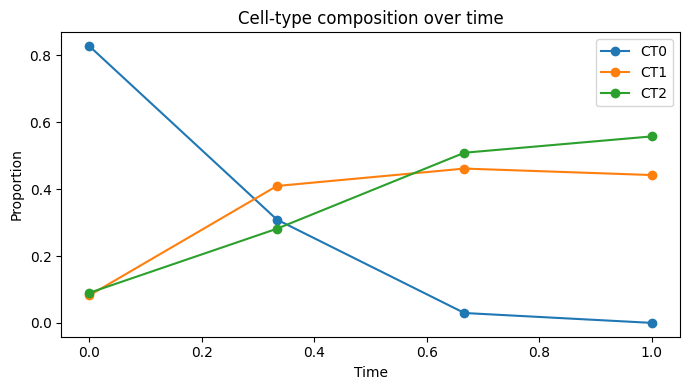

In [3]:
import matplotlib.pyplot as plt

comp_long = composition_df.melt(
    id_vars=["sample_id", "time"],
    value_vars=["CT0", "CT1", "CT2"],
    var_name="cell_type",
    value_name="proportion"
)

plt.figure(figsize=(7, 4))
for ct in ["CT0", "CT1", "CT2"]:
    sub = comp_long[comp_long["cell_type"] == ct]
    avg = sub.groupby("time")["proportion"].mean()
    plt.plot(avg.index, avg.values, marker="o", label=ct)

plt.xlabel("Time")
plt.ylabel("Proportion")
plt.title("Cell-type composition over time")
plt.legend()
plt.tight_layout()
plt.show()

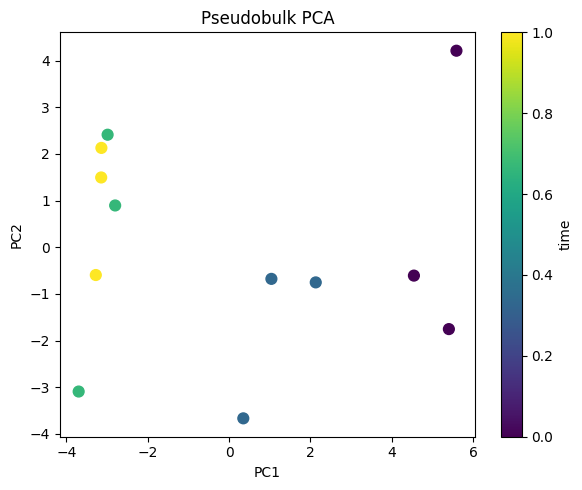

In [4]:
from sklearn.decomposition import PCA
import numpy as np

X = np.log1p(pseudobulk_df.T.values)
pca = PCA(n_components=2, random_state=0)
emb = pca.fit_transform(X)

plot_df = sample_meta.copy()
plot_df["PC1"] = emb[:, 0]
plot_df["PC2"] = emb[:, 1]

plt.figure(figsize=(6, 5))
sc = plt.scatter(plot_df["PC1"], plot_df["PC2"], c=plot_df["time"], s=60)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Pseudobulk PCA")
plt.colorbar(sc, label="time")
plt.tight_layout()
plt.show()

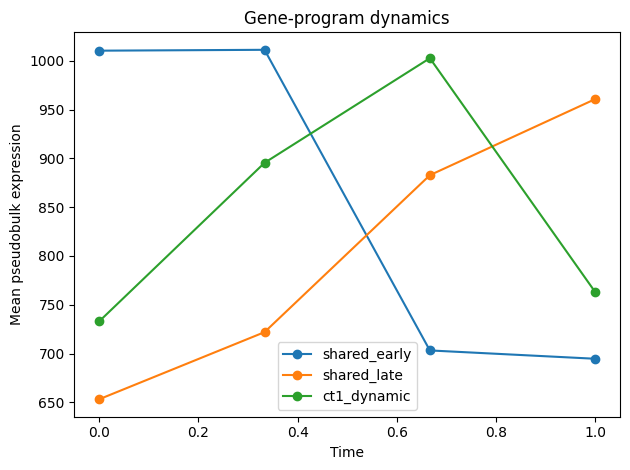

In [5]:
gene_sets = {
    "shared_early": gene_meta.loc[gene_meta["program"] == "shared_early", "gene_id"].tolist(),
    "shared_late": gene_meta.loc[gene_meta["program"] == "shared_late", "gene_id"].tolist(),
    "ct1_dynamic": gene_meta.loc[gene_meta["program"] == "dynamic_ct1", "gene_id"].tolist(),
}

for name, genes in gene_sets.items():
    vals = pseudobulk_df.loc[genes].mean(axis=0)
    tmp = pd.DataFrame({
        "sample_id": vals.index,
        "mean_expr": vals.values
    }).merge(sample_meta, on="sample_id")

    avg = tmp.groupby("time")["mean_expr"].mean()

    plt.plot(avg.index, avg.values, marker="o", label=name)

plt.xlabel("Time")
plt.ylabel("Mean pseudobulk expression")
plt.title("Gene-program dynamics")
plt.legend()
plt.tight_layout()
plt.show()